In [1]:
from preamble_jax import *
from scipy.optimize import curve_fit

Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11)]
CPU devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11)]


2025-12-01 15:55:18,898 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


In [2]:
_params_config={
    # Ramp Model Parameters
    "r1": (17.0,18.5),
    "r2": (-8.0,-6.5),
    "r3": (-0.0001,0.0001),
    #Breathing params
    "b1":(-0.01,0.01),
    "b2":(-0.01,0.01),
    "b3":(-0.01,0.01),
    "b4":(-0.01,0.01),
    # Planetary Parameters
    "a_rstar": (18.0,18.5),
    "ecc": (0.0,0.2),
    "t0": (-0.001,0.001),
    # Stellar Parameters
    "f_cool_unocculted":(0.2,0.4),
    "spec_scale_factor": (0.95, 1.05),
    "T_unocculted": (2900,3100),
    "T_occulted": (3300,3450),    
    "T_phot": (3800,4100),
    "log_fixedspot_radii":(-1.8,-1.5), #This is the size scale of spots at the active latitudes
    # This spot is occulted
    "spot1_lon": (0.85,0.89),
    "spot1_lat": (1.79,1.83),
    "spot1_rad": (0.05,0.07),
    "spot2_lon":(-0.3,0.5),
    "spot2_lat":(1.4,1.51),
    "spot2_rad":(0.3,0.32),
    #This spot controls the overall rotational modulation
    "spot3_lon": (-1.1,-0.8),
    "spot3_lat": (0.9,1.6),
    "spot3_rad": (0.15,0.25),
}

_priors={
    # Ramp Model Parameters
    "r1": (5.0, 30.0),
    "r2": (-20, -1.0),
    "r3": (-0.01, 0.01),
    #Breathing params
    "b1": (-0.5, 0.5),
    "b2": (-0.5, 0.5),
    "b3": (-0.5, 0.5),
    "b4": (-0.5, 0.5),
    # Transit Parameters
    "a_rstar": (17.0, 21.0),
    "ecc": (0.0,0.2),
    "t0": (-0.001,0.001),
    # Stellar Parameters
    "f_cool_unocculted": (0.1,0.6),
    "spec_scale_factor": (0.5, 1.5),
    "T_unocculted": (2850,3150),
    "T_occulted": (3300,3500),    
    "T_phot": (3800,4150),
    "log_fixedspot_radii": (-3,-1),
    "spot1_lon": (0.8, 0.92),
    "spot1_lat": (1.7, 1.85),
    "spot1_rad": (0.0, 0.15),
    "spot2_lon": (0.0,1.4),
    "spot2_lat": (1.2,1.6),
    "spot2_rad": (0.0,0.5),
    "spot3_lon": (-1.4, 0.0),
    "spot3_lat": (0.8, 1.8),
    "spot3_rad": (0.0, 0.6),
}

In [3]:
def bin_testing(visit='F21',bin_edges = None,
                print_results='True',plot='True'):

    predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
    binwidth = visits[f'{visit}']['native resolution']
    exptime = visits[f'{visit}']['exp (s)']
    grism = visits[f'{visit}']['Grism']
    
    rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
    for i in range(len(rainbow.wavelength.value)):
        'ADD CORRECTION TO UNCERTAINTIES'
        rainbow.uncertainty[i,:] = rainbow.uncertainty[i,:] #* SED_err_factor[i]
    data_wavelengths = rainbow.wavelength.value
    img_date = rainbow.time.value
    _data_flux = rainbow.flux.value
    time_from_T0 = img_date - predicted_T0

    mean_data_flux = np.nanmean(_data_flux, axis=1)
    data_flux = _data_flux / mean_data_flux[:, np.newaxis]
    relative_err = rainbow.uncertainty.value/_data_flux

    # Label the orbits
    orbit = np.zeros_like(img_date)
    for j in range(len(img_date)):
        if j >= 1:
            if (img_date[j] - img_date[j - 1]) > 0.01:
                orbit[j] = (orbit[j - 1] + 1)
            else:
                orbit[j] = orbit[j - 1]
    
    # Trim the first point from each orbit
    ref_time = []
    for o in np.unique(orbit):
        first_index = np.where(orbit == o)[0][0]
        ref_time.append(img_date[first_index])
        data_flux[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
        relative_err[:, first_index] = np.nan
        img_date[first_index] = np.nan
        time_from_T0[first_index] = np.nan
    
    # Set data to nan if it was in the pre-defined list of orbits to exclude
    for orbit_to_exclude in np.array([0,3,4,5]):
        data_flux[:, orbit == orbit_to_exclude] = np.nan
        relative_err[:, orbit == orbit_to_exclude] = np.nan
        img_date[orbit == orbit_to_exclude] = np.nan
        time_from_T0[orbit == orbit_to_exclude] = np.nan
    
    # Populate ramp_phase time arrays
    phase_list=[]
    for o in [0,1,2,3,4,5,6,7]:
        rphase = (img_date[orbit==o] - ref_time[o]) / 0.066
        phase_list.append(rphase)
    ramp_phase = np.concatenate(phase_list)
    
    nanmask = ~np.isnan(img_date)
    data_flux = data_flux[:,nanmask]
    relative_err = relative_err[:,nanmask]
    time_from_T0 = time_from_T0[nanmask]  
    img_date = img_date[nanmask]          
    ramp_phase = ramp_phase[nanmask]
    
    def linear_model(x, m, b):
    
        ramp = ramp_model(phase=ramp_phase,r1=17.8,r2=-7,r3=0)
    
        return (m * x + b)*ramp
    
    # Residual function (for minimization)
    def residual(params, x, y):
        m, b = params
        model = linear_model(x, m, b)
        return y - model # Residual = data - model
        
    'PLOT EACH LIGHT CURVE WITH THE MODEL, NEXT TO THE RESIDUALS'
    # fig, axes = plt.subplots(1,2,figsize=(10, 1.5))
    popt_list = []
    initial_guess = [-0.03, 1.0]  # m, b
    for i in range(len(data_wavelengths)):
        # for ax in axes:
        #     ax.clear()
        
        time = time_from_T0
        flux = data_flux[i, :]
        err = relative_err[i, :]
    
        # Fit using curve_fit
        popt, pcov = curve_fit(
            lambda x, m, b: linear_model(x, m, b),
            time,
            flux,
            sigma = err,
            p0=initial_guess,
            maxfev = 100000
        )
        # Best-fit parameters
        popt_list.append(popt)
        m_opt, b_opt = popt
        # print("Best-fit params:", popt)
        model_flux = linear_model(time_from_T0, m_opt, b_opt)
        residual = data_flux[i,:]-model_flux
        rms = int(np.nanstd(residual)*1e6)
        chisq = np.nansum((residual/relative_err[i,:])**2)
        rchisq = chisq/(np.sum(~np.isnan(time_from_T0))-2)
            
        if print_results:
            if i == 0:
                print('Wavelength Median_rel_err linear_rms r_chisq')
            print(f'{data_wavelengths[i]:.5f} {int(np.nanmedian(relative_err[i,:])*1e6)} {rms} {rchisq:.3f}')
        # axes[0].set_title(f'{data_wavelengths[i]:.5f} micron')
        # axes[1].set_title(f'Residual RMS = {rms} ppm')
        # axes[0].errorbar(img_date, data_flux[i,:],yerr=relative_err[i,:],fmt='o',
        #                  ms=1, label = f'Reduced chi-squared = {rchisq:.3f}',color='b')
        # axes[0].legend(loc = 'upper right')
        # axes[0].plot(img_date, model_flux,color='r')
        # axes[1].scatter(img_date, data_flux[i,:]-model_flux,s=1)
        # plt.savefig(f'../figs/{visit}_unbinned_lc_{i}.png')
    
    'RMS and Bin Edge Plots'
    if plot:
        fig, axes = plt.subplots(4,1,figsize=(8.5, 9),sharex=True)
        axes[2].set_title(f'{visit} Nbins = {len(bin_edges)-1}')
        axes[0].set_title(f'Data - Model (slope x ramp)')
        axes[3].set_xlabel(r'Wavelength $\mu$m')
        axes[0].set_ylabel(f'RMS (ppm)')
        axes[1].set_ylabel(r'Reduced $\chi^2$')
        axes[2].set_ylabel(f'RMS (ppm)')
        axes[3].set_ylabel(r'Reduced $\chi^2$')
    rms_list = []
    for i in range(len(data_wavelengths)):
        m_opt, b_opt = popt_list[i]
        model_flux = linear_model(time_from_T0, m_opt, b_opt)
        residual = data_flux[i,:]-model_flux
        rms = int(np.nanstd(residual)*1e6)
        rms_list.append(rms )
        chisq = np.nansum((residual/relative_err[i,:])**2)
        rchisq = chisq/(np.sum(~np.isnan(time_from_T0))-2)
        if plot:
            axes[0].scatter(data_wavelengths[i], rms,color='pink',zorder=100)
            axes[1].scatter(data_wavelengths[i], rchisq, color='k',zorder=100)

    if plot:
        for edge in bin_edges.value:
            axes[0].axvline(edge,color='r',alpha = 0.5)
            axes[1].axvline(edge,color='r',alpha = 0.5)
            axes[2].axvline(edge,color='r',alpha = 0.5)
            axes[3].axvline(edge,color='r',alpha = 0.5)
        axes[0].plot(data_wavelengths, rms_list,color='k')

    # Now do this again but with a binnned light curve

    predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
    binwidth = visits[f'{visit}']['native resolution']
    exptime = visits[f'{visit}']['exp (s)']
    grism = visits[f'{visit}']['Grism']
    
    rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
    for i in range(len(rainbow.wavelength.value)):
        'ADD CORRECTION TO UNCERTAINTIES'
        rainbow.uncertainty[i,:] = rainbow.uncertainty[i,:] #* SED_err_factor[i]
    rainbow = rainbow.bin(wavelength_edges=bin_edges)
    
    data_wavelengths = rainbow.wavelength.value
    img_date = rainbow.time.value
    _data_flux = rainbow.flux.value
    relative_err = rainbow.uncertainty.value/_data_flux
    time_from_T0 = img_date - predicted_T0

    mean_data_flux = np.nanmean(_data_flux, axis=1)
    data_flux = _data_flux / mean_data_flux[:, np.newaxis]
    
    # Label the orbits
    orbit = np.zeros_like(img_date)
    for j in range(len(img_date)):
        if j >= 1:
            if (img_date[j] - img_date[j - 1]) > 0.01:
                orbit[j] = (orbit[j - 1] + 1)
            else:
                orbit[j] = orbit[j - 1]
    
    # Trim the first point from each orbit
    ref_time = []
    for o in np.unique(orbit):
        first_index = np.where(orbit == o)[0][0]
        ref_time.append(img_date[first_index])
        data_flux[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
        relative_err[:, first_index] = np.nan
        img_date[first_index] = np.nan
        time_from_T0[first_index] = np.nan
    
    # Set data to nan if it was in the pre-defined list of orbits to exclude
    for orbit_to_exclude in np.array([0,3,4,5]):
        data_flux[:, orbit == orbit_to_exclude] = np.nan
        relative_err[:, orbit == orbit_to_exclude] = np.nan
        img_date[orbit == orbit_to_exclude] = np.nan
        time_from_T0[orbit == orbit_to_exclude] = np.nan
    
    # Populate ramp_phase time arrays
    phase_list=[]
    for o in [0,1,2,3,4,5,6,7]:
        rphase = (img_date[orbit==o] - ref_time[o]) / 0.066
        phase_list.append(rphase)
    ramp_phase = np.concatenate(phase_list)
    
    nanmask = ~np.isnan(img_date)
    data_flux = data_flux[:,nanmask]
    relative_err = relative_err[:,nanmask]
    time_from_T0 = time_from_T0[nanmask]  
    img_date = img_date[nanmask]          
    ramp_phase = ramp_phase[nanmask]
        
    'PLOT EACH LIGHT CURVE WITH THE MODEL, NEXT TO THE RESIDUALS'
    # lc_fig, lc_axes = plt.subplots(1,2,figsize=(10, 1.5))
    popt_list = []
    for i in range(len(data_wavelengths)):
        # for ax in axes:
        #     ax.clear()
        
        time = time_from_T0
        flux = data_flux[i, :]
        err = relative_err[i, :]
    
        # Fit using curve_fit
        popt, pcov = curve_fit(
            lambda x, m, b: linear_model(x, m, b),
            time,
            flux,
            sigma = err,
            p0=initial_guess,
            maxfev = 100000
        )
        # Best-fit parameters
        popt_list.append(popt)
        m_opt, b_opt = popt
        model_flux = linear_model(time_from_T0, m_opt, b_opt)
        residual = data_flux[i,:]-model_flux
        rms = int(np.nanstd(residual)*1e6)
        chisq = np.nansum((residual/relative_err[i,:])**2)
        rchisq = chisq/(np.sum(~np.isnan(time_from_T0))-2)
        if print_results:
            if i == 0:
                print('BINNED: Wavelength Median_rel_err linear_rms r_chisq')
            print(f'{data_wavelengths[i]:.5f} {int(np.nanmedian(relative_err[i,:])*1e6)} {rms} {rchisq:.3f}')
        # lc_axes[0].set_title(f'{data_wavelengths[i]:.5f} micron')
        # lc_axes[1].set_title(f'Residual RMS = {rms} ppm')
        # lc_axes[0].errorbar(img_date, data_flux[i,:],yerr=relative_err[i,:],fmt='o',
        #                  ms=1, label = f'Reduced chi-squared = {rchisq:.3f}',color='b')
        # lc_axes[0].legend(loc = 'upper right')
        # lc_axes[0].plot(img_date, model_flux,color='r')
        # lc_axes[1].scatter(img_date, data_flux[i,:]-model_flux,s=1)
        # plt.savefig(f'../figs/{visit}_binned_lc_{i}.png')
    
    'PLOT THE RMS'
    rms_list = []
    for i in range(len(data_wavelengths)):
        m_opt, b_opt = popt_list[i]
        model_flux = linear_model(time_from_T0, m_opt, b_opt)
        residual = data_flux[i,:]-model_flux
        rms = int(np.nanstd(residual)*1e6)
        rms_list.append( rms )
        chisq = np.nansum((residual/relative_err[i,:])**2)
        rchisq = chisq/(np.sum(~np.isnan(time_from_T0))-2)
        if plot:
            axes[2].scatter(data_wavelengths[i], rms,color='pink',zorder=100)
            axes[3].scatter(data_wavelengths[i], rchisq,color='k',zorder=100)
            

    if plot:
        axes[2].plot(data_wavelengths, rms_list,color='k')
        plt.savefig(f'../../figs/{visit}_{len(bin_edges)-1}bins_rms_plots.png')
        plt.show()

    return rms_list

1.14064
1.16381
1.18234
1.20087
1.21477
1.23793
1.25647
1.28426
1.31669
1.33059
1.34449
1.35839
1.39082
1.40935
1.42325
1.43715
1.45568
1.47421
1.51127
1.5298
1.54834
1.5715
1.62246
1.645
Wavelength Median_rel_err linear_rms r_chisq
1.12906 357 587 2.753
1.13369 356 5979 288.717
1.13832 357 5147 212.907
1.14296 353 1617 21.417
1.14759 349 414 1.447
1.15222 346 1364 15.929
1.15685 346 1963 32.894
1.16149 346 3190 86.813
1.16612 342 833 6.048
1.17075 339 1706 25.976
1.17539 336 1529 21.212
1.18002 334 1356 16.783
1.18465 332 496 2.280
1.18929 330 644 3.881
1.19392 329 2645 66.321
1.19855 328 1061 10.663
1.20318 326 451 1.967
1.20782 323 404 1.606
1.21245 321 487 2.361
1.21708 320 2329 54.358
1.22172 318 2001 40.373
1.22635 316 505 2.605
1.23098 315 1230 15.602
1.23561 314 1423 20.903
1.24025 313 721 5.402
1.24488 313 1428 21.239
1.24951 313 938 9.173
1.25415 312 308 0.998
1.25878 311 405 1.736
1.26341 311 750 5.944
1.26804 311 1190 14.957
1.27268 310 1612 27.674
1.27731 309 895 8.579
1.2

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

BINNED: Wavelength Median_rel_err linear_rms r_chisq
1.15223 155 379 6.045
1.17307 169 386 5.363
1.19161 165 458 7.913
1.20782 186 384 4.350
1.22635 141 255 3.314
1.24720 156 251 2.639
1.27036 126 474 14.334
1.30048 115 334 8.587
1.32364 173 277 2.622
1.33754 173 254 2.214
1.35144 173 367 4.606
1.37460 114 264 5.447
1.40009 152 280 3.454
1.41630 174 567 10.844
1.43020 174 283 2.698
1.44642 151 313 4.413
1.46495 152 371 6.107
1.49274 108 461 18.606
1.52053 150 345 5.374
1.53907 151 319 4.534
1.55992 136 453 11.395
1.59698 92 427 21.670
1.63373 141 382 7.515


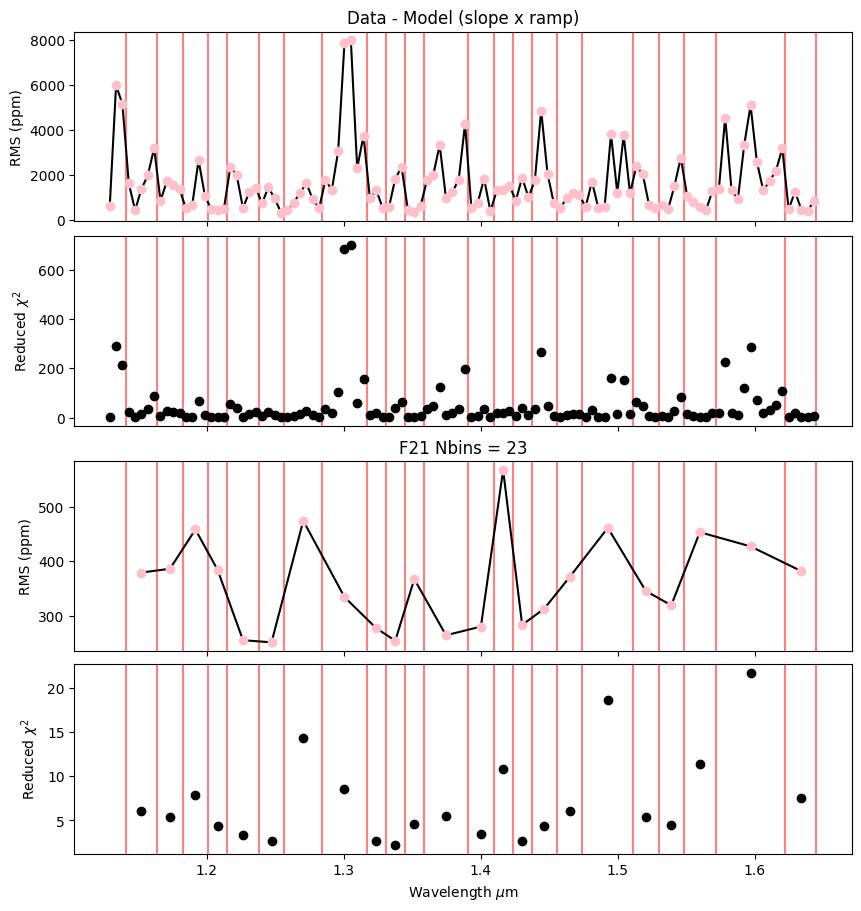

In [4]:
'FOR THE TRANSMISSION LIGHT CURVES'
visit = 'F21'
SED_err_factor = F21_SED_err_factor
F21_bin_edges = np.array([1.122105, 1.159170,
                          1.210135, 1.25183, 1.28426,
                          # 1.288895,
                          1.325955, 1.34912, 1.390815,
                          1.413980, 
                          # 1.437145, 
                          1.460305, 1.488105,
                          1.5298, 1.566865,
                          # 1.608560,
                          1.62245,1.64]) * u.micron

F21_bin_edges =jnp.array([#1.13138,
# 1.13601,
1.14064,
# 1.14528,
# 1.14991,
# 1.15454,
# 1.15917,
1.16381,
# 1.16844,
# 1.17307,
# 1.17771,
1.18234,
# 1.18697,
# 1.19161,
# 1.19624,
1.20087,
# 1.20550,
# 1.21014,
1.21477,
# 1.22404,
# 1.22867,
# 1.23330,
1.23793,
# 1.24257,
# 1.24720,
# 1.25183,
1.25647,
# 1.26110,
# 1.26573,
# 1.27036,
# 1.27500,
# 1.27963,
1.28426,
# 1.28890,
# 1.29353,
# 1.29816,
# 1.30279,
# 1.30743,
# 1.31206,
1.31669,
# 1.32133,
# 1.32596,
1.33059,
# 1.33522,
# 1.33986,
1.34449,
# 1.34912,
# 1.35376,
1.35839,
# 1.36302,
# 1.36765,
# 1.37229,
# 1.37692,
# 1.38155,
# 1.38619,
1.39082,
# 1.39545,
# 1.40008,
# 1.40472,
1.40935,
# 1.41398,
# 1.41862,
1.42325,
# 1.42788,
# 1.43251,
1.43715,
# 1.44178,
# 1.44641,
# 1.45105,
1.45568,
# 1.46031,
# 1.46494,
# 1.46958,
1.47421,
# 1.47884,
# 1.48348,
# 1.48811,
# 1.49274,
# 1.49737,
# 1.50201,
# 1.50664,
1.51127,
# 1.51591,
# 1.52054,
# 1.52517,
1.52980,
# 1.53444,
# 1.53907,
# 1.54370,
1.54834,
# 1.55297,
# 1.55760,
# 1.56223,
# 1.56687,
1.57150,
# 1.57613,
# 1.58077,
# 1.58540,
# 1.59003,
# 1.59466,
# 1.59930,
# 1.60393,
# 1.60856,
# 1.61320,
# 1.61783,
1.62246,
# 1.62709,
# 1.63173,
# 1.63636,
# 1.64099,
1.645])*u.micron

for edge in F21_bin_edges:
    print(edge.value)
    
rms = bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

Wavelength Median_rel_err linear_rms r_chisq
0.80708 647 707 1.229
0.80954 633 712 1.304
0.81200 618 618 1.029
0.81446 607 705 1.389
0.81691 600 1134 3.654
0.81937 593 1130 3.723
0.82183 573 538 0.904
0.82429 554 514 0.885
0.82675 539 606 1.302
0.82921 531 752 2.065
0.83167 524 823 2.535
0.83412 519 710 1.931
0.83658 514 824 2.639
0.83904 509 947 3.569
0.84150 500 893 3.273
0.84396 497 930 3.606
0.84642 492 1008 4.330
0.84887 487 1422 8.773
0.85133 485 1456 9.303
0.85379 482 1431 9.081
0.85625 472 863 3.438
0.85871 473 946 4.126
0.86117 467 1006 4.774
0.86362 466 997 4.715
0.86608 465 1235 7.256
0.86854 455 780 3.018
0.87100 441 533 1.503
0.87346 430 588 1.918
0.87592 425 639 2.333
0.87838 420 562 1.844
0.88083 419 710 2.953
0.88329 412 529 1.693
0.88575 407 710 3.121
0.88821 405 658 2.721
0.89067 401 562 2.024
0.89313 400 687 3.045
0.89558 393 609 2.469
0.89804 389 565 2.171
0.90050 389 741 3.740
0.90296 388 604 2.497
0.90542 383 646 2.914
0.90788 382 574 2.329
0.91034 377 449 1.465
0

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

BINNED: Wavelength Median_rel_err linear_rms r_chisq
0.81034 313 551 3.194
0.81937 340 578 2.975
0.82675 312 494 2.579
0.85010 122 858 50.927
0.87469 214 494 5.460
0.88452 205 528 6.810
0.89681 160 531 11.277
0.90788 219 420 3.757
0.91648 182 421 5.503
0.92754 158 503 10.333
0.94107 141 430 9.509
0.95459 149 558 14.344
0.96442 191 469 6.210
0.97057 232 504 4.863
0.97548 230 445 3.853
0.98163 185 388 4.502
1.00007 92 505 30.990
1.01974 155 434 8.000
1.02834 177 417 5.680
1.03449 217 412 3.716
1.04063 176 372 4.612
1.05047 136 429 10.189
1.06153 152 403 7.215
1.07013 174 406 5.598
1.08734 90 639 51.084
1.10701 134 396 8.908
1.11807 151 412 7.678
1.12650 180 344 3.772


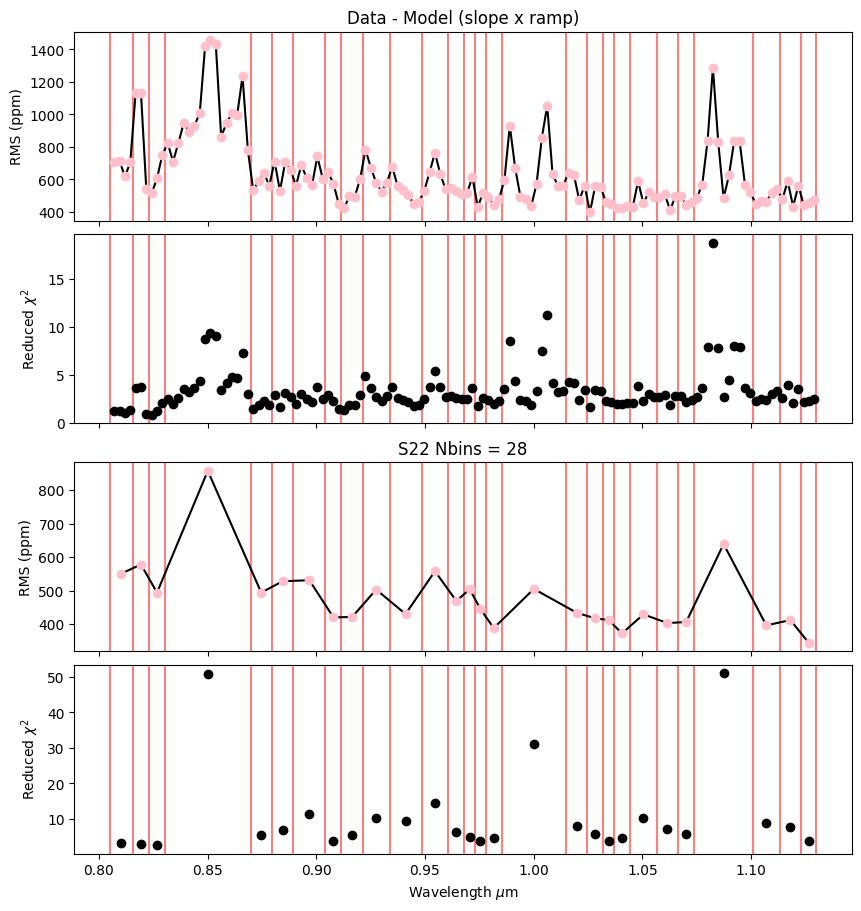

0.805
0.81568514
0.82306047
0.8304358
0.8697709
0.87960467
0.88943845
0.90418911
0.91156444
0.92139821
0.93369043
0.94844109
0.96073331
0.96810864
0.97302553
0.97794241
0.98531775
1.01481907
1.02465284
1.03202817
1.03694506
1.04432039
1.05661261
1.06644638
1.07382171
1.10086459
1.11315681
1.12299059
1.13


In [23]:
'FOR TRANSMISSION LIGHT CURVES:'
visit = 'S22'
SED_err_factor = S22_SED_err_factor



S22_bin_edges = np.array([0.805,
                   # 0.80830981, 0.81076825, 
                   # 0.81322669, 
                   0.81568514, 
                   # 0.81814358,
       # 0.82060202, 
                   0.82306047, 
                   # 0.82551891, 
                   # 0.82797736, 
                   0.8304358 ,
       # 0.83289424, 
                   # 0.83535269, 
                   # 0.83781113, 
                   # 0.84026957, 
                   # 0.84272802,
       # 0.84518646, 
                   # 0.8476449 , 
                   # 0.85010335, 
                   # 0.85256179, 
                   # 0.85502023,
       # 0.85747868, 
                   # 0.85993712, 
                   # 0.86239557, 
                   # 0.86485401, 
                   # 0.86731245,
       0.8697709 , 
                   # 0.87222934, 
                   # 0.87468778, 
                   # 0.87714623, 
                   0.87960467,
       # 0.88206311, 
                   # 0.88452156, 
                   # 0.88698   , 
                   0.88943845, 
                   # 0.89189689,
       # 0.89435533, 
                   # 0.89681378, 
                   # 0.89927222, 
                   # 0.90173066, 
                   0.90418911,
       # 0.90664755, 
                   # 0.90910599, 
                   0.91156444, 
                   # 0.91402288, 
                   # 0.91648132,
       # 0.91893977, 
                   0.92139821, 
                   # 0.92385666, 
                   # 0.9263151 , 
                   # 0.92877354,
       # 0.93123199, 
                   0.93369043, 
                   # 0.93614887, 
                   # 0.93860732, 
                   # 0.94106576,
       # 0.9435242 , 
                   # 0.94598265, 
                   0.94844109, 
                   # 0.95089954, 
                   # 0.95335798,
       # 0.95581642, 
                   # 0.95827487, 
                   0.96073331, 
                   # 0.96319175, 0.9656502 ,
       0.96810864, 
                   # 0.97056708, 
                   0.97302553, 
                   # 0.97548397, 
                   0.97794241,
       # 0.98040086, 
                   # 0.9828593 , 
                   0.98531775, 
                   # 0.98777619, 
                   # 0.99023463,
       # 0.99269308, 
                   # 0.99515152, 
                   # 0.99760996, 
                   # 1.00006841, 
                   # 1.00252685,
       # 1.00498529, 
                   # 1.00744374, 
                   # 1.00990218, 
                   # 1.01236062, 
                   1.01481907,
       # 1.01727751, 
                   # 1.01973596, 
                   # 1.0221944 , 
                   1.02465284, 
                   # 1.02711129,
       # 1.02956973, 
                   1.03202817, 
                   # 1.03448662, 
                   1.03694506, 
                   # 1.0394035 ,
       # 1.04186195, 
                   1.04432039, 
                   # 1.04677884, 
                   # 1.04923728, 
                   # 1.05169572,
       # 1.05415417, 
                   1.05661261, 
                   # 1.05907105, 
                   # 1.0615295 , 
                   # 1.06398794,
       1.06644638, 
                   # 1.06890483, 
                   # 1.07136327, 
                   1.07382171, 
                   # 1.07628016,
       # 1.0787386 , 
                   # 1.08119705, 
                   # 1.08365549, 
                   # 1.08611393, 
                   # 1.08857238,
       # 1.09103082, 
                   # 1.09348926, 
                   # 1.09594771,
                   # 1.09840615, 
                          1.10086459,
       # 1.10332304, #1.10578148, 1.10823993, 1.11069837, 
                   1.11315681,
       #1.11561526, 1.1180737 , 1.12053214, 
                   1.12299059, 1.13]) * u.micron


_rms = bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)

for edge in S22_bin_edges:
    print(edge.value)

In [ ]:
# S22_bin_edges = np.array([0.791,0.81077,
#                           0.82306,
                          
#                           0.83535,0.85010,0.85502,0.85748,

#                           # 0.83044,0.83290,0.83535,0.83781,0.84027,0.84273,
#                           # 0.84519,0.84765,0.85010,0.85256,0.85502,0.85748,
#                           # 0.85994,0.86240,0.86485,0.86731,0.86977,
#                           # 0.87223,0.87469,0.87715,0.87961,0.88206,
#                           # 0.88452,0.88698,0.88944,0.89190,
#                           0.85994,
#                           #  0.8919 , 
                          
#                           0.90173, 0.91157, 0.91894,
#                           0.93123, 0.93861, 0.94598, 0.95828,
#                           0.96811, 0.9804,  0.99761,
#                           1.0099 , 1.01974, 1.03449,
#                           1.04432, 1.0517, 1.06399, 
#                           # 1.06645,1.06891,1.07136,1.08611,1.10087,1.10332,1.10824,1.11562,
#                           1.07382,1.07628,1.08857,1.10087, 1.11562, 
#                           1.13037]) * u.micron


  0%|          | 0/45 [00:00<?, ?it/s]

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

...

  0%|          | 0/162 [00:00<?, ?it/s]

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

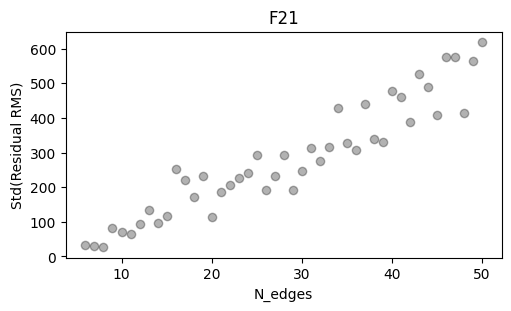

  0%|          | 0/45 [00:00<?, ?it/s]

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

...

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

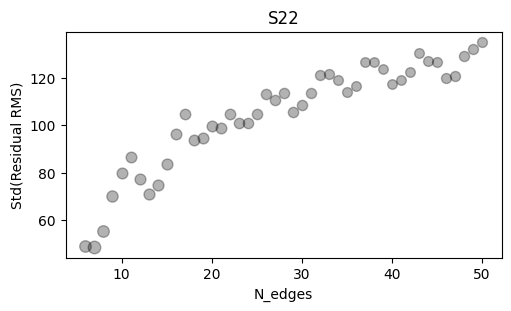

<Figure size 640x480 with 0 Axes>

In [6]:
visit = 'F21'
fig, ax = plt.subplots(1,1,figsize=(5,3))
for N_edges in tqdm(list(range(6, 51))):

    n_edges = int(N_edges)
    new_bin_edges = np.linspace(1.135,1.645,n_edges) * u.micron
    _rms = bin_testing(visit='F21',bin_edges = new_bin_edges,
            print_results = False,plot=False)
    rms = np.nanstd(_rms)
    mean_rms = np.nanmean(_rms)
    max_rms = np.nanmax(_rms)/rms
    rms_stat = np.nanmin(_rms)/np.nanmean(_rms)

    ax.scatter(n_edges, rms, color='k',alpha=0.3)

ax.set_xlabel('N_edges')
ax.set_ylabel('Std(Residual RMS)')
ax.set_title('F21')
plt.savefig(f'../../figs/{visit}_rmsvsbinsize.png')
plt.show()
plt.clf()

visit = 'S22'
fig, ax = plt.subplots(1,1,figsize=(5,3))
for N_edges in tqdm(list(range(6, 51))):

    n_edges = int(N_edges)
    new_bin_edges = np.linspace(0.86,1.13,n_edges) * u.micron
    _rms = bin_testing(visit='S22',bin_edges = new_bin_edges,
            print_results = False,plot=False)
    rms = np.nanstd(_rms)
    mean_rms = np.nanmean(_rms)
    max_rms = np.nanmax(_rms)/rms
    rms_stat = np.nanmin(_rms)/np.nanmean(_rms)

    ax.scatter(n_edges, rms,s=float((rms_stat*10)**2),color='k',alpha=0.3)

ax.set_xlabel('N_edges')
ax.set_ylabel('Std(Residual RMS)')
ax.set_title('S22')
plt.savefig(f'../../figs/{visit}_rmsvsbinsize.png')
plt.show()
plt.clf()